## Regularization as variance reduction in Linear Regression

The goal of this notebook is to illustrate how regularization can be interpreted as a variance reduction technique in the context of linear regression. We will generate syncthetic datasets with varying levels of noise and observe how regularization affects the variance of the model's predictions and weights

The notebook is separated in two step:
1. Show how variance affects the model's weights and predictions in linear regression.
2. Show how regularization can reduce the variance of the model's weights and predictions.

In [1]:
"""Signal to estimate"""

import numpy as np

SLOPE = 2.66
INTERCEPT = 4.21

def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

## How the data is built

The `generate_dataset` function builds a stack of datasets with progressively higher variance along `axis=0`. Each dataset shares the same `x` samples and clean signal `y = f(x)`, but a different amount of Gaussian noise is added to `y`. The noise levels are equally spaced between `0` and `noise_upto`, so the first dataset in the stack is noise-free and the last one has the highest variance. The larger `noise_upto` is, the noisier (and more spread out) the final dataset becomes.

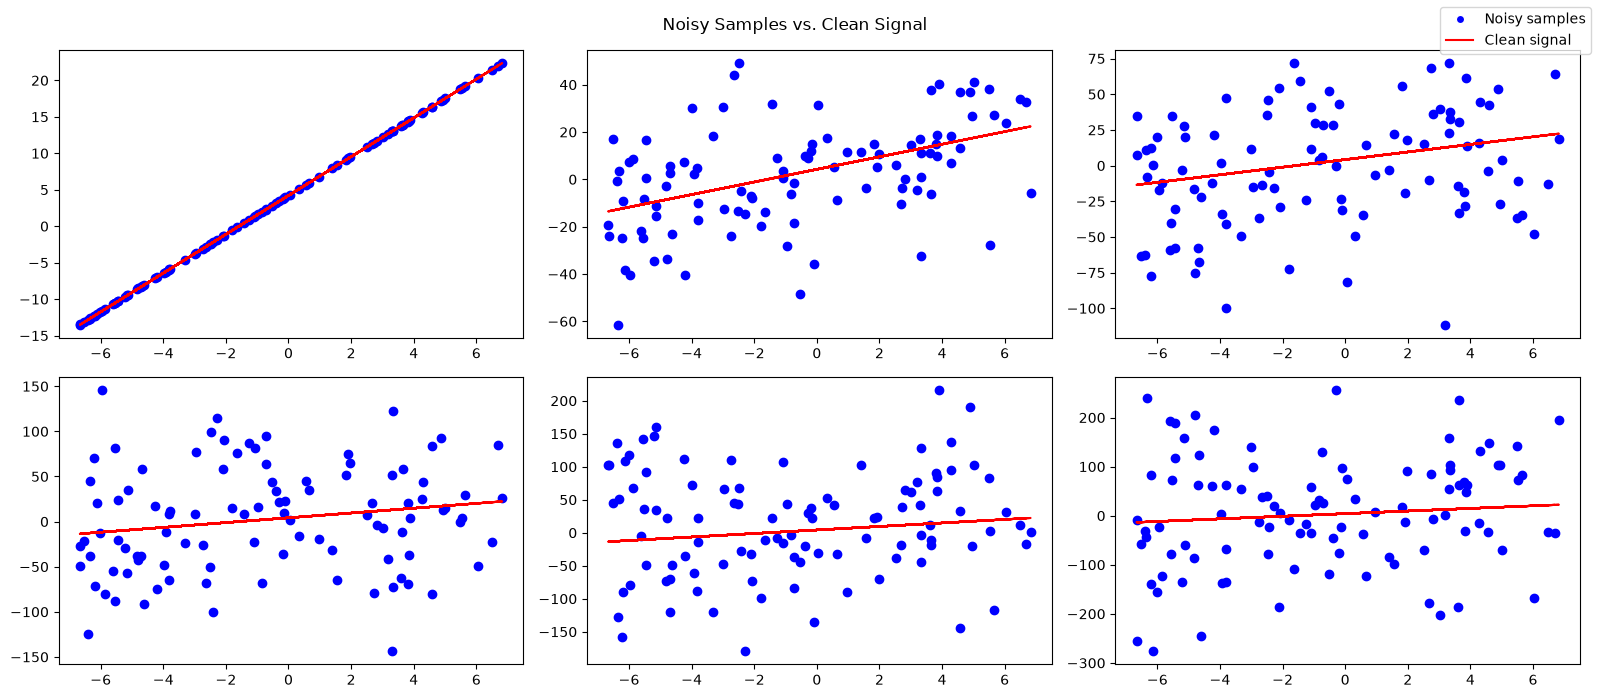

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from examples.helpers.dataset import generate_dataset
from examples.helpers.graph import generate_axs, plot_dataset, scatter_dataset


MIN = -7
MAX = 7
SEED = 777
DATASETS_SIZE = 6
SAMPLE_SIZE = 100
NOISE_UPTO = 100

X = generate_dataset(f, size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=NOISE_UPTO, min=MIN, max=MAX, seed=SEED)
X_clean = generate_dataset(f, size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=0, min=MIN, max=MAX, seed=SEED)

fig, axs = generate_axs(X.shape[0])
scatter_dataset(X, fig, axs)
plot_dataset(X_clean, fig, axs)

fig.suptitle("Noisy Samples vs. Clean Signal")
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Noisy samples'),
    Line2D([0], [0], color='red', label='Clean signal'),
], loc='upper right')

fig.tight_layout()
plt.show()

## STEP 1: Show how variance affects the model's weights and predictions in linear regression.

## Training the models

For each noise level, `generate_noise_repeats` draws `N_REPEATS` independent datasets — same `x` samples, same signal, but freshly sampled Gaussian noise added to `y` each time. Every repeat gets its own `Trainer` (fresh `Sequential(Linear(1, 1))`, `MSELoss`, `SGD`, `CosineSchedule`) and is trained from scratch with `fit_model`.

The final parameters and loss history of every repeat, at every noise level, are collected into `all_params`, `all_train_loss` and `all_eval_loss` for the analysis below.

In [3]:
import numpy as np
from examples.helpers.dataset import generate_noise_dataset
from examples.helpers.train import create_trainer, fit_model, get_model_param, preprocess_dataloader, split_dataset


EPOCHS = 80
EVAL_STEP = 10
BATCH_SIZE = 16
N_REPEATS = 20
MAX_LR, MIN_LR = 1e-2, 1e-4
IN_FEATURE, OUT_FEATURE = 1, 1

all_params = []
all_train_loss = []   # (DATASETS_SIZE, N_REPEATS, EPOCHS)
all_eval_loss = []    # (DATASETS_SIZE, N_REPEATS, EPOCHS/EVAL_STEP)
noise_levels = np.linspace(0, NOISE_UPTO, DATASETS_SIZE)

for noise in noise_levels:
    level_params, level_train_loss, level_eval_loss = [], [], []

    repeats = generate_noise_dataset(f, N_REPEATS, SAMPLE_SIZE, noise, MIN, MAX, SEED)
    tr, te = split_dataset(repeats, split_ratio=0.9, axis=1)

    for sample_tr, sample_te in zip(tr, te):
        loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE)
        trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS) # ADD WEIGHTS DECAY

        fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)

        level_params.append(get_model_param(trainer.model))
        level_train_loss.append(trainer.train_loss)
        level_eval_loss.append(trainer.eval_loss)
    
    all_params.append(level_params)
    all_train_loss.append(level_train_loss)
    all_eval_loss.append(level_eval_loss)

all_params = np.array(all_params)
all_train_loss = np.array(all_train_loss) 
all_eval_loss = np.array(all_eval_loss) 


## Loss and Weights spread

Instead of a single final loss per noise level, we now have `N_REPEATS` of them. We take the last evaluation loss of every repeat (`all_eval_loss[:, :, -1]`) and draw one boxplot per noise level, so both the typical loss and its spread across repeats are visible at once.

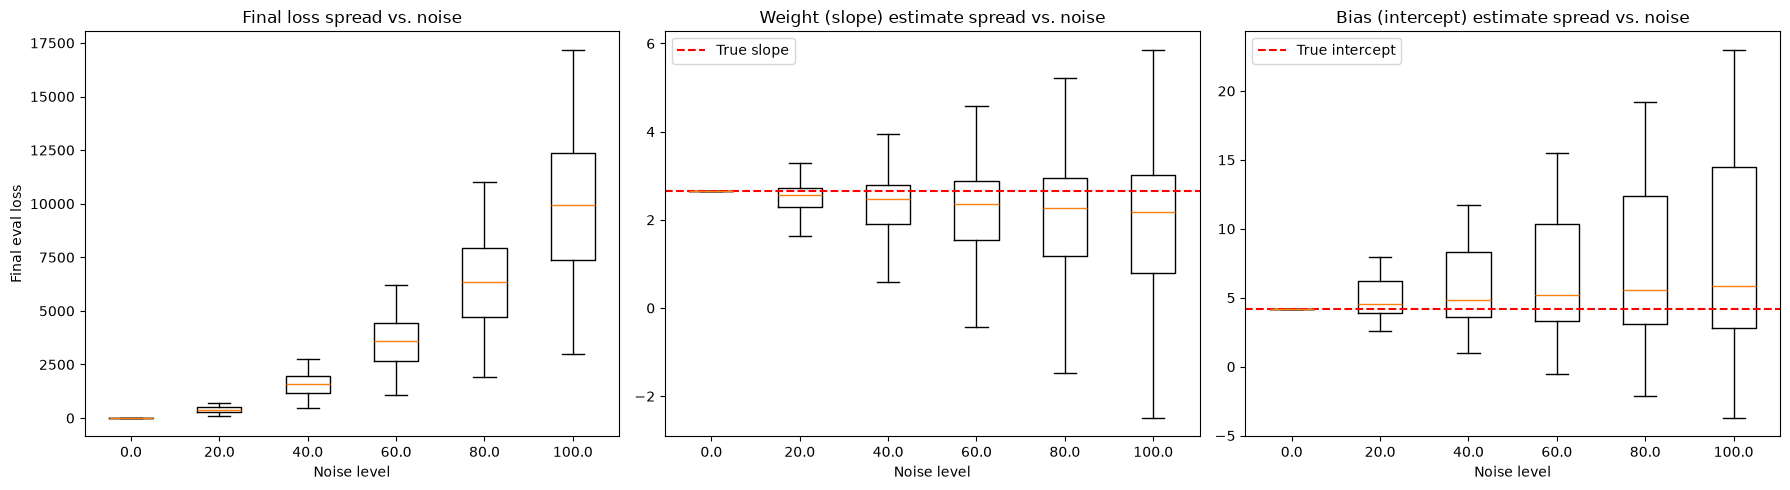

In [4]:
final_eval_loss = all_eval_loss[:, :, -1]  # (DATASETS_SIZE, N_REPEATS)

weight_samples = all_params[:, :, 0, 0, 0]
bias_samples   = all_params[:, :, 1, 0, 0]

fig, (ax_loss, ax_w, ax_b) = plt.subplots(1, 3, figsize=(18, 5))

ax_loss.boxplot(final_eval_loss.T, positions=noise_levels, widths=NOISE_UPTO/DATASETS_SIZE*0.6)
ax_loss.set_xlabel("Noise level")
ax_loss.set_ylabel("Final eval loss")
ax_loss.set_title("Final loss spread vs. noise")

ax_w.boxplot(weight_samples.T, positions=noise_levels, widths=NOISE_UPTO/DATASETS_SIZE*0.6)
ax_w.axhline(SLOPE, color='red', linestyle='--', label='True slope')
ax_w.set_title("Weight (slope) estimate spread vs. noise")
ax_w.set_xlabel("Noise level")
ax_w.legend()

ax_b.boxplot(bias_samples.T, positions=noise_levels, widths=NOISE_UPTO/DATASETS_SIZE*0.6)
ax_b.axhline(INTERCEPT, color='red', linestyle='--', label='True intercept')
ax_b.set_title("Bias (intercept) estimate spread vs. noise")
ax_b.set_xlabel("Noise level")
ax_b.legend()

fig.tight_layout()
plt.show()

## Consideration

As we can see, the weights and losses spread increases with the noise level, and the final evaluation loss also increases. This is expected, as higher noise levels make it harder for the model to learn the underlying signal.


## STEP 2: Show how regularization can reduce the variance of the model's weights and predictions.

## Regularization

The regularization term is added to the SGD optimizer, which penalizes large weights and encourages the model to find simpler solutions. We will use L2 regularization (Ridge regression) in this example.

In these training loops, the decay term is isolated from the noise term, so we can see how increasing the regularization strength affects the model's weights and predictions, while keeping the noise level fixed.

In [5]:
import numpy as np
from examples.helpers.dataset import generate_noise_dataset
from examples.helpers.train import create_trainer, fit_model, get_model_param, preprocess_dataloader, split_dataset


EPOCHS = 80
EVAL_STEP = 10
BATCH_SIZE = 16
N_REPEATS = 20
DECAY_UPTO = 10
MAX_LR, MIN_LR = 1e-2, 1e-4
IN_FEATURE, OUT_FEATURE = 1, 1
FIXED_NOISE = NOISE_UPTO  # keep noise fixed at Step 1's noisiest level so the sweep below isolates the weight_decay effect

all_params = []
all_train_loss = []   # (DATASETS_SIZE, N_REPEATS, EPOCHS)
all_eval_loss = []    # (DATASETS_SIZE, N_REPEATS, EPOCHS/EVAL_STEP)
decay_levels = np.linspace(0, DECAY_UPTO, DATASETS_SIZE)

for decay in decay_levels:
    level_params, level_train_loss, level_eval_loss = [], [], []

    repeats = generate_noise_dataset(f, N_REPEATS, SAMPLE_SIZE, FIXED_NOISE, MIN, MAX, SEED)
    tr, te = split_dataset(repeats, split_ratio=0.9, axis=1)

    for sample_tr, sample_te in zip(tr, te):
        loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE)
        trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS, decay)

        fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)

        level_params.append(get_model_param(trainer.model))
        level_train_loss.append(trainer.train_loss)
        level_eval_loss.append(trainer.eval_loss)

    all_params.append(level_params)
    all_train_loss.append(level_train_loss)
    all_eval_loss.append(level_eval_loss)

all_params = np.array(all_params)
all_train_loss = np.array(all_train_loss)
all_eval_loss = np.array(all_eval_loss)

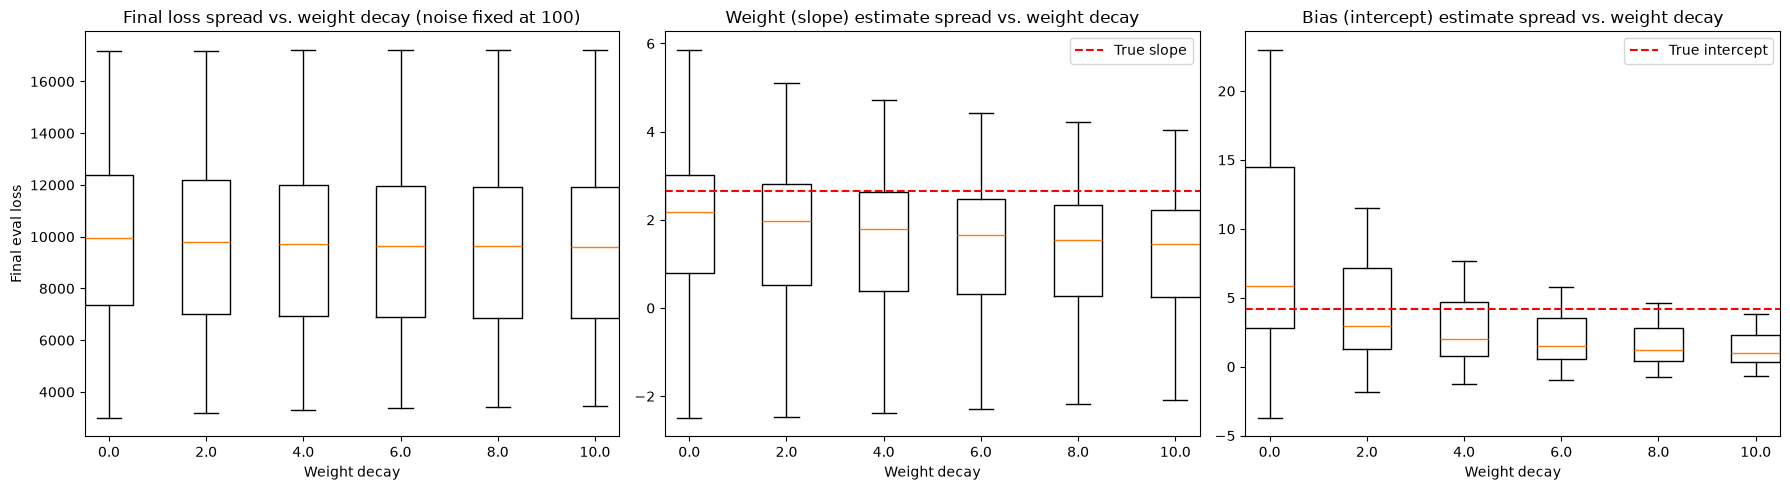

In [6]:
final_eval_loss = all_eval_loss[:, :, -1]  # (DATASETS_SIZE, N_REPEATS)

weight_samples = all_params[:, :, 0, 0, 0]
bias_samples   = all_params[:, :, 1, 0, 0]

fig, (ax_loss, ax_w, ax_b) = plt.subplots(1, 3, figsize=(18, 5))

ax_loss.boxplot(final_eval_loss.T, positions=decay_levels, widths=DECAY_UPTO/DATASETS_SIZE*0.6)
ax_loss.set_xlabel("Weight decay")
ax_loss.set_ylabel("Final eval loss")
ax_loss.set_title(f"Final loss spread vs. weight decay (noise fixed at {FIXED_NOISE:.0f})")

ax_w.boxplot(weight_samples.T, positions=decay_levels, widths=DECAY_UPTO/DATASETS_SIZE*0.6)
ax_w.axhline(SLOPE, color='red', linestyle='--', label='True slope')
ax_w.set_title("Weight (slope) estimate spread vs. weight decay")
ax_w.set_xlabel("Weight decay")
ax_w.legend()

ax_b.boxplot(bias_samples.T, positions=decay_levels, widths=DECAY_UPTO/DATASETS_SIZE*0.6)
ax_b.axhline(INTERCEPT, color='red', linestyle='--', label='True intercept')
ax_b.set_title("Bias (intercept) estimate spread vs. weight decay")
ax_b.set_xlabel("Weight decay")
ax_b.legend()

fig.tight_layout()
plt.show()

## Consideration

With noise held fixed at Step 1's highest level, increasing `weight_decay` visibly tightens both the weight and bias spread — the variance-reduction effect regularization is meant to demonstrate.

The trade-off is also visible: as `weight_decay` grows, the weight and bias means drift away from the true `SLOPE`/`INTERCEPT` lines toward `0` — the classic bias-variance tradeoff. The bias (intercept) drifts noticeably faster than the weight, because this `SGD` implementation applies `weight_decay` to every parameter returned by `model.parameters`, including the bias term — unlike frameworks that exclude bias from decay by default.